This notebook develops and evaluates machine learning models for bearing fault classification using the engineered vibration features extracted from the CWRU dataset.

Objectives:

Objectives

• Prevent data leakage using file-based splitting

• Develop a baseline model

• Train Decision Tree

• Train Random Forest

• Compare model performance

• Generate confusion matrices

• Analyse feature importance



# Imports Library

In [38]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

# Load Dataset

In [39]:
df = pd.read_csv(
    "phase1_full_dataset.csv"
)

df.head()

,Mean,RMS,Std,Peak,Peak_to_Peak,Skewness,Kurtosis,Crest_Factor,Shape_Factor,Impulse_Factor,...,BPFO_BPFI_Ratio,Band_0_500,Band_500_1000,Band_1000_2000,Wavelet_D1,Wavelet_D2,Wavelet_D3,Wavelet_D4,Label,Source_File
0,0.012421,0.075982,0.074960,0.217794,0.416396,-0.162976,-0.243664,2.866393,1.232692,3.533380,...,0.509594,147.551131,95.658846,161.241849,0.036103,0.559792,3.431540,0.423184,0,97.mat
1,0.012693,0.073679,0.072577,0.272869,0.485031,-0.156544,0.021868,3.703495,1.247336,4.619501,...,2.293648,146.979278,79.725276,165.712824,0.037583,0.547612,3.135956,0.373435,0,97.mat
2,0.011589,0.070425,0.069465,0.272869,0.485031,-0.107386,0.184817,3.874580,1.262097,4.890095,...,2.921649,143.471074,90.892121,139.916615,0.038085,0.537930,2.639634,0.416981,0,97.mat
3,0.011424,0.072956,0.072056,0.211536,0.386147,0.081507,-0.304845,2.899512,1.251572,3.628947,...,0.432535,140.360081,87.465467,163.903410,0.039168,0.596414,3.155051,0.418865,0,97.mat
4,0.014643,0.078377,0.076996,0.212370,0.420569,0.050329,-0.376182,2.709618,1.242484,3.366659,...,0.507850,152.797162,64.809815,170.830579,0.038150,0.632442,3.519659,0.337282,0,97.mat


# Dataset Shape

In [40]:
print(df.shape)

df["Label"].value_counts()

(6153, 25)


Label
0    3310
3     949
1     948
2     946
Name: count, dtype: int64

# Remove Non-Predictive Columns

In [77]:
# ==========================================================
# Features for Live InfluxDB Prediction
# ==========================================================

feature_columns = [
    "Mean",
    "Peak",
    "Peak_to_Peak",
    "RMS",
    "Std"
]

X = df[feature_columns]

y = df["Label"]

groups = df["Source_File"]
y = df["Label"]

groups = df["Source_File"]

# Prevent Data Leakage

In [78]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        X,
        y,
        groups=groups
    )
)

# Create Train/Test Sets

In [79]:
X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

# Verify No Leakage

In [80]:
train_files = set(
    groups.iloc[train_idx]
)

test_files = set(
    groups.iloc[test_idx]
)

print(
    train_files.intersection(
        test_files
    )
)

set()


In [81]:
print(train_files)

print(test_files)

{'119.mat', '108.mat', '97.mat', '121.mat', '99.mat', '130.mat', '107.mat', '106.mat', '131.mat', '132.mat', '133.mat', '120.mat'}
{'98.mat', '105.mat', '118.mat', '100.mat'}


In [82]:
print(y_test.value_counts())

Label
0    1891
2     238
1     235
Name: count, dtype: int64


# Baseline Model (Decision Tree)

A Decision Tree is used as a baseline model for comparison.

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(
    X_train,
    y_train
)

dt_pred = dt_model.predict(
    X_test
)

dt_accuracy = accuracy_score(
    y_test,
    dt_pred
)

print(
    "Decision Tree Accuracy:",
    dt_accuracy
)

# Decision Tree Report

In [83]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

In [84]:
print(
    classification_report(
        y_test,
        dt_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1891
           1       1.00      1.00      1.00       235
           2       1.00      1.00      1.00       238

    accuracy                           1.00      2364
   macro avg       1.00      1.00      1.00      2364
weighted avg       1.00      1.00      1.00      2364



# Decision Tree Confusion Matrix

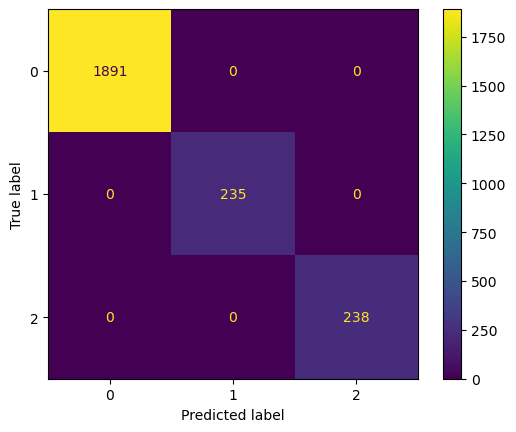

In [85]:
cm = confusion_matrix(
    y_test,
    dt_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.show()

# Random Forest

In [86]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(
    X_test
)

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print(
    "Random Forest Accuracy:",
    rf_accuracy
)

Random Forest Accuracy: 1.0


# Random Forest Report

In [87]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1891
           1       1.00      1.00      1.00       235
           2       1.00      1.00      1.00       238

    accuracy                           1.00      2364
   macro avg       1.00      1.00      1.00      2364
weighted avg       1.00      1.00      1.00      2364



# Random Forest Confusion Matrix

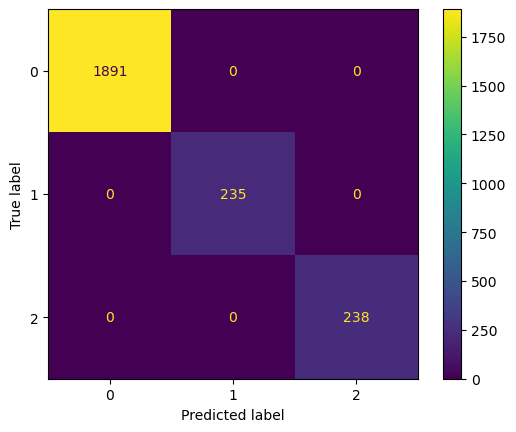

In [88]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.show()

# Feature Importance

In [89]:
feature_importance = pd.DataFrame(
{
    "Feature": X.columns,
    "Importance":
        rf_model.feature_importances_
}
)

feature_importance = (
    feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
)

feature_importance.head(10)

,Feature,Importance
4,Std,0.277185
3,RMS,0.260631
2,Peak_to_Peak,0.237601
1,Peak,0.224583
0,Mean,0.000000


# Plot Feature Importance

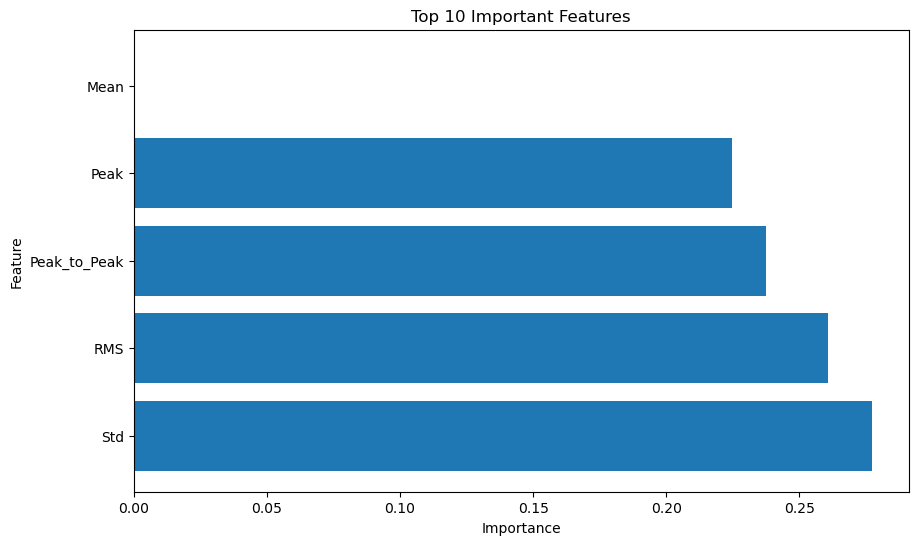

In [90]:
top_features = (
    feature_importance
    .head(10)
)

plt.figure(
    figsize=(10,6)
)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel(
    "Importance"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Top 10 Important Features"
)

plt.show()

# Model Comparison Table

In [91]:
comparison = pd.DataFrame(
{
    "Model": [
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        dt_accuracy,
        rf_accuracy
    ]
}
)

comparison

,Model,Accuracy
0,Decision Tree,1.0
1,Random Forest,1.0


# Save Results

In [92]:
comparison.to_csv(
    "model_comparison.csv",
    index=False
)

print(
    "Results saved."
)

Results saved.


# Initial Group-Based Validation Result

In [93]:
print(y_test.value_counts())

Label
0    1891
2     238
1     235
Name: count, dtype: int64


In [94]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1891
           1       1.00      1.00      1.00       235
           2       1.00      1.00      1.00       238

    accuracy                           1.00      2364
   macro avg       1.00      1.00      1.00      2364
weighted avg       1.00      1.00      1.00      2364



# Validation Review

In [95]:
print("Train Files:")
print(sorted(train_files))

print("\nTest Files:")
print(sorted(test_files))

print("\nTest Class Distribution:")
print(y_test.value_counts())

Train Files:
['106.mat', '107.mat', '108.mat', '119.mat', '120.mat', '121.mat', '130.mat', '131.mat', '132.mat', '133.mat', '97.mat', '99.mat']

Test Files:
['100.mat', '105.mat', '118.mat', '98.mat']

Test Class Distribution:
Label
0    1891
2     238
1     235
Name: count, dtype: int64


# Save Random Forest.pk1 file

In [96]:
import joblib

joblib.dump(rf_model, "random_forest_model.pkl")

print("Random Forest model saved successfully.")

Random Forest model saved successfully.


In [99]:
print(rf_model.n_features_in_)

5


In [97]:
print(type(rf_model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [98]:
print(X.columns.tolist())

['Mean', 'Peak', 'Peak_to_Peak', 'RMS', 'Std']
